# Autoencoder in PyTorch

In [53]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')
import ice

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
import pathlib
import datetime

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
# load simulation data
Eb = loadmat("../data/NGrIS/ensemble_data_pixelated/enthalpy_basal_grid.mat")['enthalpy_basal_grid']
Em = loadmat("../data/NGrIS/ensemble_data_pixelated/enthalpy_avg_grid.mat")['enthalpy_avg_grid']
pmp = loadmat("../data/NGrIS/ensemble_data_pixelated/pmp_grid.mat")['pmp_grid']
radar_mask = loadmat("../data/NGrIS/ensemble_data_pixelated/radar_mask.mat")['radar_mask']

Eb = np.array(Eb)
Em = np.array(Em)
pmp = pmp[:, :, np.newaxis]
pmp = np.tile(pmp, (1, 1, Eb.shape[2]))

# convert Em to attenu rate
Tb = ice.enthalpy_to_temperature(Eb, Tpmp = pmp, istorch = False)
Tm = ice.enthalpy_to_temperature(Em, Tpmp = pmp, istorch = False)

# # check for non convergent samples, generate graphs for each sample
# Tb_save_path = "../data/NGrIS/ensemble_data_pixelated/Eb_samples/"
# pathlib.Path(Tb_save_path).mkdir(parents=True, exist_ok=True)
# Tm_save_path = "../data/NGrIS/ensemble_data_pixelated/Em_samples/"
# pathlib.Path(Tm_save_path).mkdir(parents=True, exist_ok=True)

# for i in range(Tb.shape[2]):
#     fig, ax = plt.subplots()
#     im1 = ax.imshow(Tb[:, :, i], vmin = 240, vmax = 273.15)
#     plt.colorbar(im1)
#     ax.set_title(f"Eb sample {i+1}")
#     fig.savefig(f"{Tb_save_path}Tb_{i+1}.png")
#     plt.close(fig)

#     fig, ax = plt.subplots()
#     im2 = ax.imshow(Tm[:, :, i], vmin = 240, vmax = 273.15)
#     plt.colorbar(im2)
#     ax.set_title(f"Em sample {i+1}")
#     fig.savefig(f"{Tm_save_path}Tm_{i+1}.png")
#     plt.close(fig)

# remove samples that did not converge


# convert Tm to attenu rate
attenu = ice.temperature_to_attenu_rate(Tm)

non_convergence_idx = np.arange(attenu.shape[2])[np.all(np.isnan(attenu), axis = (0, 1))]
attenu = np.delete(attenu, non_convergence_idx, axis = 2)

transformer_Eb = sklearn.preprocessing.StandardScaler()
transformer_attenu = sklearn.preprocessing.StandardScaler()

Eb_standard = transformer_Eb.fit_transform(Eb.reshape(-1, 1))
Eb_standard = Eb_standard.reshape(int(np.sqrt(np.shape(Eb_standard)[0]/Eb.shape[2])), int(np.sqrt(np.shape(Eb_standard)[0]/Eb.shape[2])), Eb.shape[2])

attenu_fromEm_standard = transformer_attenu.fit_transform(attenu.reshape(-1, 1))
attenu_fromEm_standard = attenu_fromEm_standard.reshape(int(np.sqrt(np.shape(attenu_fromEm_standard)[0]/attenu.shape[2])), int(np.sqrt(np.shape(attenu_fromEm_standard)[0]/attenu.shape[2])), attenu.shape[2])

# filter points not on radar flight path
attenu_fromEm_standard[np.tile(radar_mask[:, :, np.newaxis], (1, 1, attenu_fromEm_standard.shape[2])) != 1] = 0
attenu_fromEm_standard = np.moveaxis(attenu_fromEm_standard, -1, 0)
attenu_fromEm_standard = attenu_fromEm_standard[:, np.newaxis, :, :]
attenu_fromEm_standard[np.isnan(attenu_fromEm_standard)] = 0
attenu_fromEm_standard = torch.tensor(attenu_fromEm_standard).float()

Eb_standard = np.moveaxis(Eb_standard, -1, 0)
Eb_standard = Eb_standard[:, np.newaxis, :, :]
Eb_standard[np.isnan(Eb_standard)] = 0
Eb_standard = torch.tensor(Eb_standard).float()

In [55]:
# # load attenuation rate data from observation and generate samples assuming normal distribution
# attenu_mean = loadmat("../data/NGrIS/ensemble_data_pixelated/radar_attenu_rate_mean_grid.mat")['radar_attenu_rate_mean_grid']
# attenu_std = loadmat("../data/NGrIS/ensemble_data_pixelated/radar_attenu_rate_uncertainty_grid.mat")['radar_attenu_rate_uncertainty_grid']

# n_samples_attenu = 300
# # using shape suitable for tensor flow, n_sample * 1 * image dimension * image dimension
# attenu = np.zeros((n_samples_attenu, 1, attenu_mean.shape[0], attenu_mean.shape[1]))
# for i in range(n_samples_attenu):
#     attenu[i, 0, :, :] = np.random.normal(attenu_mean, attenu_std)

# attenu_fromEm_standard = attenu.copy()
# attenu_fromEm_standard = attenu_fromEm_standard - np.tile(attenu_mean[np.newaxis, np.newaxis, :, :], (n_samples_attenu, 1, 1, 1))
# attenu_fromEm_standard = attenu_fromEm_standard / np.tile(attenu_std[np.newaxis, np.newaxis, :, :], (n_samples_attenu, 1, 1, 1))
# attenu_fromEm_standard[np.isnan(attenu_fromEm_standard)] = 0
# attenu_fromEm_standard = torch.tensor(attenu_fromEm_standard).float()

In [56]:
class Net(nn.Module):

    def __init__(self, image_dimension, batch_size, kernel_1_size = 3, kernel_2_size = 7):
      super(Net, self).__init__()

      dimension_after_conv = image_dimension - (kernel_1_size // 2) * 2 - (kernel_2_size // 2) * 2

      self.encoder = nn.Sequential(
        nn.Conv2d(1, 1, kernel_1_size, 1),
        nn.ReLU(),
        nn.Conv2d(1, 1, kernel_2_size, 1),
        nn.ReLU(),
        nn.Flatten(start_dim=1),
        nn.Linear(dimension_after_conv ** 2, 128),
        nn.Linear(128, 32),
        nn.Sigmoid()
      )
      self.decoder = nn.Sequential(
        nn.Sigmoid(),
        nn.Linear(32, 128),
        nn.Linear(128, dimension_after_conv ** 2),
        nn.Unflatten(dim=1, unflattened_size = (1, dimension_after_conv, dimension_after_conv)),
        nn.ReLU(),
        nn.ConvTranspose2d(1, 1, kernel_2_size, 1),
        nn.ReLU(),
        nn.ConvTranspose2d(1, 1, kernel_1_size, 1)
      )
    
    def main(self, x):
       x = self.encoder(x)
       x = self.decoder(x)
       return x

In [57]:
torch.autograd.set_detect_anomaly(True)

num_epochs = 50
batch_size = 4

attenu_fromEm_dataset = TensorDataset(attenu_fromEm_standard, attenu_fromEm_standard)

train_size = (int(0.7 * len(attenu_fromEm_standard)) // 4) * 4
val_size = int((len(attenu_fromEm_standard) - train_size)/2)
test_size = int(len(attenu_fromEm_standard) - train_size - val_size)

generator = torch.Generator().manual_seed(42)
attenu_fromEm_train_dataset, attenu_fromEm_val_dataset, attenu_fromEm_test_dataset = random_split(attenu_fromEm_dataset, [train_size, val_size, test_size], generator=generator)

attenu_fromEm_train_dataloader = DataLoader(attenu_fromEm_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_fromEm_val_dataloader = DataLoader(attenu_fromEm_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_fromEm_test_dataloader = DataLoader(attenu_fromEm_test_dataset, batch_size = batch_size, shuffle = 1)


model = Net(image_dimension = attenu_fromEm_standard.shape[2], batch_size = batch_size, kernel_1_size = 3, kernel_2_size = 5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
epoch_loss = []
epoch_loss_val = []

for epoch in range(num_epochs):
    start = torch.Event(enable_timing=True)
    end = torch.Event(enable_timing=True)

    start.record()

    model.train()
    running_loss = 0.0
    running_loss_val = 0.0
    for train_batch, _ in attenu_fromEm_train_dataloader:
        
        outputs = model.main(train_batch)
        loss = criterion(outputs, train_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * train_batch.size(0)
    
    for val_batch, _ in attenu_fromEm_val_dataloader:
        outputs = model.main(val_batch)
        loss = criterion(outputs, val_batch)

        running_loss_val += loss.item() * val_batch.size(0)
    
    epoch_loss.append(running_loss / len(attenu_fromEm_train_dataloader.dataset))
    epoch_loss_val.append(running_loss_val / len(attenu_fromEm_val_dataloader.dataset))

    end.record()

    print(f"Epoch [{epoch + 1}/{num_epochs}], loss: {epoch_loss[epoch]:.4f}, validation loss: {epoch_loss_val[epoch]:.4f}, time elapsed = {start.elapsed_time(end)/1000:.2f} s")
    
    if epoch > 1:
        if epoch_loss_val[-1] > epoch_loss_val[-2]:
            print("Validation loss increased, early stopping")
            break

Epoch [1/50], loss: 0.0443, validation loss: 0.0379, time elapsed = 1.74 s
Epoch [2/50], loss: 0.0333, validation loss: 0.0288, time elapsed = 1.73 s
Epoch [3/50], loss: 0.0260, validation loss: 0.0233, time elapsed = 1.75 s
Epoch [4/50], loss: 0.0218, validation loss: 0.0201, time elapsed = 1.79 s
Epoch [5/50], loss: 0.0193, validation loss: 0.0183, time elapsed = 1.74 s
Epoch [6/50], loss: 0.0178, validation loss: 0.0172, time elapsed = 1.73 s
Epoch [7/50], loss: 0.0170, validation loss: 0.0165, time elapsed = 1.69 s
Epoch [8/50], loss: 0.0164, validation loss: 0.0161, time elapsed = 1.70 s
Epoch [9/50], loss: 0.0161, validation loss: 0.0159, time elapsed = 1.75 s
Epoch [10/50], loss: 0.0159, validation loss: 0.0157, time elapsed = 1.78 s
Epoch [11/50], loss: 0.0157, validation loss: 0.0156, time elapsed = 1.80 s
Epoch [12/50], loss: 0.0156, validation loss: 0.0155, time elapsed = 1.78 s
Epoch [13/50], loss: 0.0156, validation loss: 0.0154, time elapsed = 1.82 s
Epoch [14/50], loss: 

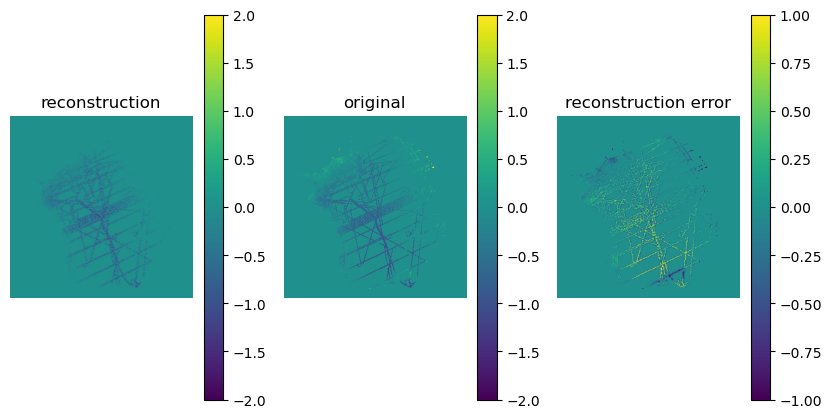

In [58]:
figs, axs = plt.subplots(1, 3, figsize = (10, 5))

im0 = axs[0].imshow(model.main(attenu_fromEm_test_dataset[0][0]).detach().numpy()[0, 0, :, :], vmin = -2, vmax = 2)
axs[0].invert_yaxis()
axs[0].axis('off')
axs[0].set_title("reconstruction")
plt.colorbar(im0)

im1 = axs[1].imshow(attenu_fromEm_test_dataset[0][1].detach().numpy()[0, :, :], vmin = -2, vmax = 2)
axs[1].invert_yaxis()
axs[1].axis('off')
axs[1].set_title("original")
plt.colorbar(im1)

im2 = axs[2].imshow((model.main(attenu_fromEm_test_dataset[0][0]) - attenu_fromEm_test_dataset[0][1]).detach().numpy()[0, 0, :, :], vmin = -1, vmax = 1)
axs[2].invert_yaxis()
axs[2].axis('off')
axs[2].set_title("reconstruction error")
plt.colorbar(im2)

In [59]:
attenu_latent = model.encoder(attenu_fromEm_standard)

torch.save(attenu_latent, 'attenu_latent.pt')
torch.save(model.state_dict(), f'autoencoder_{datetime.datetime.now()}.pth')